# Preparing Data for HMA

HMASynthesizer is the primary entry point for SDV users who want to experiment with generating multi-table synthetic data.

A common challenge that first-time users of the HMASynthesizer face is data volume: the tables in a dataset are often interconnected, and each one can contain many rows (sometimes millions). This presents a twofold problem:

- If you're running a starter experiment or a proof-of-concept, you may not want to use all of this data to develop a synthesizer. Many would rather use a subsample.
- Secondly, even if you do want to use all of it, training a synthesizer at that scale could take hours, and generating an equivalent volume of synthetic data also takes a long time.

In this tutorial, we'll show you techniques available within SDV that let you construct a subsample of your multi-table data with referential integrity. Along the way, we'll also simplify the schema by dropping a reference table that doesn't need to be synthesized.

We'll use a motivating example – testing a consumer banking application that allows customers to check their account balances, apply for loans, see a list of credit card transactions, and perform other common financial actions. We'll call the dataset we're working with the "bank credit card dataset."

In [11]:
import warnings

warnings.filterwarnings('ignore')

## Understanding the data

Here's a quick summary of what each table represents.

- **loan**: each row represents a bank loan, along with the account it's linked to
- **client**: each row represents a unique banking client
- **trans**: each row represents a financial transaction
- **account**: each row represents an account's static information
- **card**: each row represents an issued credit card, along with the account it is linked to
- **order**: each row represents the characteristics of a payment order
- **disp**: each row links together a client and an account

Here's a diagram that visualizes the relationships between these tables:

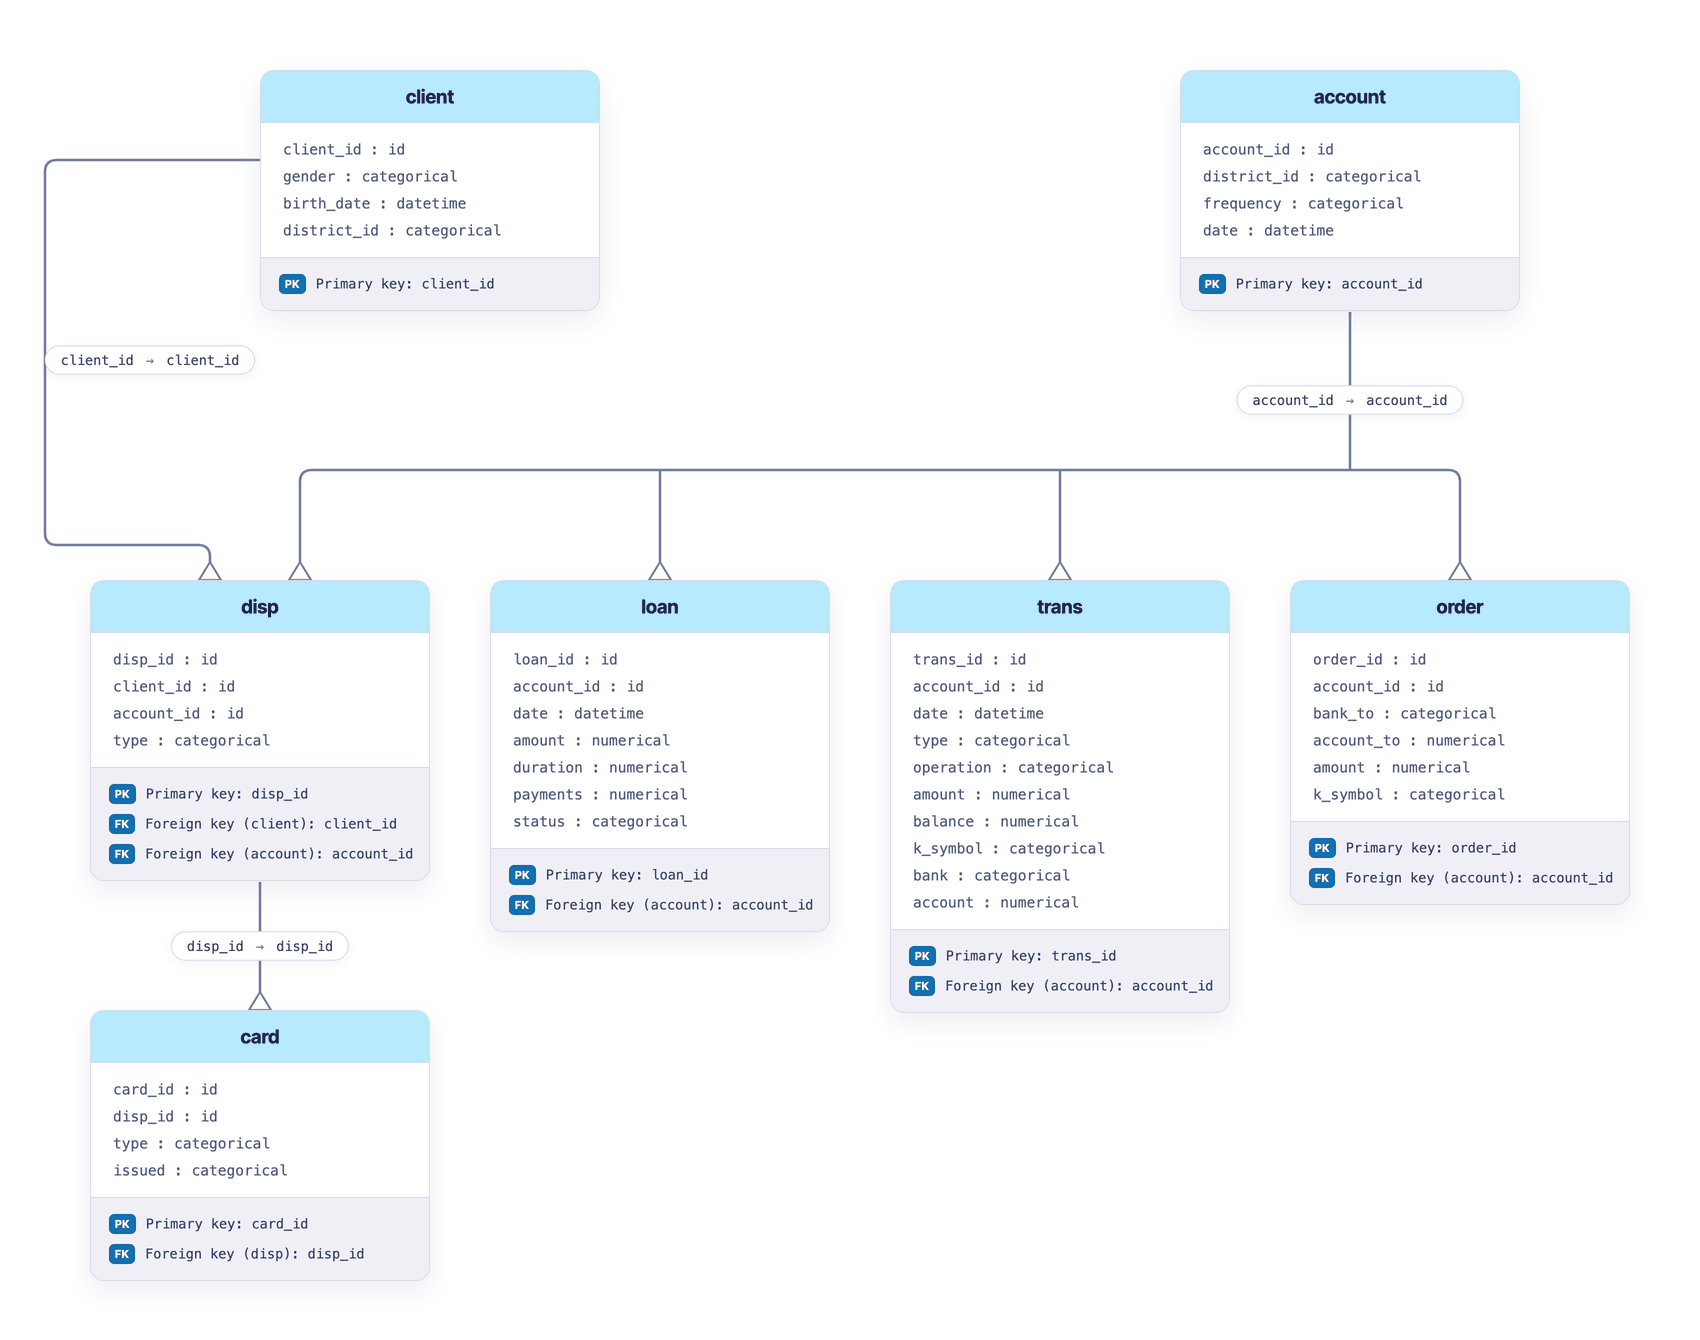

Let's load the dataset. We'll fetch the `financial` demo dataset using `download_demo`, which returns both the data and its curated metadata.

In [12]:
from sdv.datasets.demo import download_demo

real_data, multi_metadata = download_demo(
    modality='multi_table',
    dataset_name='financial',
)

The `financial` dataset ships with a `district` reference table that doesn't need to be synthesized. This is the schema-simplification step we mentioned at the start: dropping reference tables keeps the schema valid while making it easier for the HMASynthesizer to handle. We'll remove `district` and treat the `district_id` columns that referenced it as categorical.

In [13]:
real_data.pop('district')
multi_metadata.remove_table('district')

multi_metadata.update_columns_metadata(
    table_name='account',
    column_metadata={'district_id': {'sdtype': 'categorical'}},
)
multi_metadata.update_columns_metadata(
    table_name='client',
    column_metadata={'district_id': {'sdtype': 'categorical'}},
)

Let's confirm which tables are available.

In [14]:
list(real_data.keys())

['account', 'card', 'client', 'disp', 'loan', 'order', 'trans']

Let's visualize the relationships between these tables.

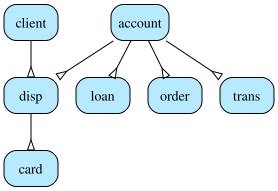

In [15]:
multi_metadata.visualize(show_table_details=None, show_relationship_labels=False)

## Why a Random Subsample Isn't Enough

Let's take a 10% random sample from all tables and then compare the overlap between the `account` and `loan` tables using the linked column.

Before:
- `real_data['account']`: 4500 rows
- `real_data['loan']`: 682 rows

After:
- `random_subset['account']`: 450 rows
- `random_subset['loan']`: 68 rows

When we compare values for the `account_id` columns in the random subset tables, only 4 of the 68 rows in the `random_subset['loan']` table match!

In [16]:
random_subset = {}

for table_name, table in real_data.items():
    row_sample_count = round(len(table) / 10)
    table = table.sample(n=row_sample_count, random_state=7).reset_index(drop=True)
    random_subset[table_name] = table

Let's inspect the data. First, the first few rows of the original `account` table:

In [17]:
real_data['account'].head(5)

,account_id,district_id,frequency,date
0,1,18,POPLATEK MESICNE,1995-03-24
1,2,1,POPLATEK MESICNE,1993-02-26
2,3,5,POPLATEK MESICNE,1997-07-07
3,4,12,POPLATEK MESICNE,1996-02-21
4,5,15,POPLATEK MESICNE,1997-05-30


And here are the first few rows after taking a 10% random sample.

In [18]:
random_subset['account'].head(5)

,account_id,district_id,frequency,date
0,378,68,POPLATEK MESICNE,1996-07-22
1,2122,68,POPLATEK MESICNE,1993-01-08
2,498,1,POPLATEK MESICNE,1993-11-21
3,2306,38,POPLATEK MESICNE,1993-12-08
4,1328,8,POPLATEK MESICNE,1996-05-04


Analyzing just 2 of the subsampled tables is enough to observe why this doesn't work: referential integrity is missing. The `account` and `loan` tables are linked together using the `account_id` column, with the `loan` table containing fewer rows (68 rows) than the `account` table (450 rows). Let's count the number of matching references between both of these columns and compare this to the full expected count.

In [19]:
int(random_subset['loan']['account_id'].isin(random_subset['account']['account_id']).sum())

4

And compare that against the total number of rows in the subsampled child table.

In [20]:
len(random_subset['loan'])

68

Out of 68 rows, it turns out that only 4 of the rows in the subsampled loan table have a corresponding `account_id` in the `account` table. For the rest of the loans, there are no associated `account_ids`. This breaks the referential integrity requirement, and makes it so that creating data with referential integrity would require dropping many of the rows in the loan table.

## Dropping Unknown References

To ensure that any random subsamples of our data maintain referential integrity, we have to remove all the rows that do not have a reference to their relevant primary key.

In SDV there is a relevant utility function called `drop_unknown_references()`. To use this function, we just need to pass in the multi-table data and our metadata to return a subsample containing no missing references. In our subsample, every child row will have a matching parent row.

> **For data to have referential integrity:**
> - Every child row in a child table must have a reference to a parent row.
> - Not every parent must have a child.

Let's use this function to drop missing references in our existing 10% subsample.

In [21]:
from sdv.utils import drop_unknown_references

cleaned_subset = drop_unknown_references(
  random_subset, multi_metadata
)

Success! All foreign keys have referential integrity.

Table Name  # Rows (Original)  # Invalid Rows  # Rows (New)
   account                450               0           450
      card                 89              86             3
    client                537               0           537
      disp                537             489            48
      loan                 68              64             4
     order                647             572            75
     trans             105632           94836         10796

The function will output a data with referential integrity and also show the number of rows remaining in the new subsample:

As we can see, many rows in many tables were removed. The summary helps us understand which rows were removed in our subsample:

- The `client` and `account` tables are parent tables, so no rows were removed. Many of these rows may not have any data in the child tables, but the data is still referentially valid.
- In line with our earlier exploration, the `loan` table shrunk massively because only 4 rows had matching `account_id` values in the `account` subset.
- Other tables that have foreign key relationships with the `account` table also shrunk massively, including `disp`, `order`, and `trans`.

Ultimately, this suggests that the approach we took has some flaws. What if we wanted to preserve a certain percentage of rows for an important table? Pulling a random subset of data and then dropping rows with missing references to the parent tables makes it hard to control the amount of overall subsampled data that has referential integrity.

## Generating a Referentially Integral Subsample of your Data

We created the `get_random_subset()` utility function to help you create a random subsample of your data at the appropriate scale while maintaining referential integrity.

To use this function, you need to supply the name of the main table (`main_table_name`) you want to center your subsampling around, and the number of rows (`num_rows`) from that table that you want in the subsample. The SDV will then traverse the linked tables (parent and child tables) and extract rows such that the resulting multi-table data has referential integrity.

To really witness the power of this function, let's use the `account` table as our main table, since it has the most linked tables. Let's aim to select 450 rows from this table (10% of the rows), and have the SDV sample the remaining tables accordingly.

In [22]:
import numpy as np
from sdv.utils.poc import get_random_subset

main_table_rows = round(len(real_data['account']) / 10)

# Seed NumPy so the random subsample (and its row counts) is reproducible
np.random.seed(7)
referential_subset = get_random_subset(
    real_data,
    multi_metadata,
    main_table_name='account',
    num_rows=main_table_rows,
)

Success! Your subset has 89% less rows than the original.

Table Name  # Rows (Before)  # Rows (After)
   account             4500             450
      card              892              95
    client             5369            5369
      disp             5369             539
      loan              682              62
     order             6471             648
     trans          1056320          108191


The function will output some statistics about the subsample:

As expected, only 450 of the 4500 rows in the `account` table were kept. The linked tables were also greatly reduced in size in the subsample. Notice that, even with 450 rows in the `account` table, we have 62 entries in the `loan` table. Compare this with the previous example, where even with 450 rows in the `account` table we were left with just 4 entries in the `loan` table.

Our subsample was centered around a 10% sample of the `account` table. How do we know if 10% of our main table is enough? More broadly, how do we determine how much data is sufficient to subsample during a POC project with HMASynthesizer?

A good rule of thumb is to cycle through the following steps until the quality is acceptable for the time it takes to generate the synthetic data:

1. Start with a small sample size of training data (e.g. 10%)
2. Train an HMASynthesizer
3. Measure how long HMA took to train and synthesize
4. Evaluate the quality of the data

If you want higher quality and find the training and synthesis time acceptable, increase the sample size and run through steps 2 - 4 again until you find the sweet spot that balances time spent and quality.

## Conclusion

Preparing multi-table data for the HMASynthesizer comes down to building a subsample that preserves referential integrity at a scale you control:

- A **naive random sample** of each table breaks referential integrity — in our example, only 4 of the 68 sampled `loan` rows referenced an `account` that was also kept.
- **`drop_unknown_references()`** restores integrity by removing the dangling rows, but it gives you no control over how much data survives.
- **`get_random_subset()`** centers the subsample on a main table and follows the relationships to keep the linked rows, so you get a referentially valid subset at the size you ask for — 450 `account` rows preserved 62 `loan` rows here, compared to just 4 with the naive approach.

With a right-sized, referentially valid subsample in hand, you're ready to train the HMASynthesizer on a proof-of-concept dataset and iterate on the sample size until quality and runtime hit your sweet spot.